attempt 1: 30min, wrote skeleton for init and loss, got mixed up on the dimensions. kept going, and got mixed up on dimensions later for forward passes. ended up falling asleep \
attempt 2: 7min, working only on auxiliary functions, got stuck on some transpose stuff \
attempt 3: 26min, still only on auxiliary functions, much better. small issues in conv backward and maxpool left \
attempt 4: 26min, auxiliary functions all good \
attempt 5: 40 min, tiny issues but overall good. diminishing returns if i repeat \

analysis after model code not written by me

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [24]:
# N, C, H, W = x.shape
# F, _, HH, WW = w.shape
# H_out = (H + 2*pad - HH) // (stride) + 1
# in init, W is F, C_in, HH, WW
# size = (size + 2*conv1['pad'] - conv1['filter_size']) // conv1['stride'] + 1
# size = (size - pp['pool_height']) // pp['stride'] + 1

In [ ]:
def relu_forward(x):
    out = np.maximum(x, 0)
    cache = x
    return out, cache

def relu_backward(dout, cache):
    x = cache
    dx = dout * (x > 0)
    return dx

def affine_forward(x, w, b):
    x_shift = x.reshape(x.shape[0], -1)
    out = np.dot(x_shift, w) + b
    cache = (x, w, b)
    return out, cache

def affine_backward(dout, cache):
    x, W, b = cache
    x_flat = x.reshape(x.shape[0], -1)
    dx = np.dot(dout, W.T).reshape(x.shape)
    dW = np.dot(x_flat.T, dout)
    db = np.sum(dout, axis=0)
    return dx, dW, db

def conv_forward(x, w, b, conv_param):
    stride, pad = conv_param['stride'], conv_param['pad']
    N, C, H, W = x.shape
    F, _, HH, WW = w.shape
    H_out = (H + 2*pad - HH) // (stride) + 1
    W_out = (W + 2*pad - WW) // (stride) + 1
    out = np.zeros((N, F, H_out, W_out))
    x_padded = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)))
    for n in range(N):
        for f in range(F):
            for i in range(H_out):
                for j in range(W_out):
                    h_start, w_start = i*stride, j*stride
                    patch = x_padded[n, :, h_start:h_start+HH, w_start:w_start+WW]
                    out[n, f, i, j] = np.sum(patch * w[f]) + b[f]
    cache = (x, w, b, conv_param)
    return out, cache


def conv_backward(dout, cache):
    # remeber that gradients are added here, since it's a loop
    x, w, b, conv_param = cache
    stride, pad = conv_param['stride'], conv_param['pad']
    N, C, H, W = x.shape
    F, _, HH, WW = w.shape
    _, _, H_out, W_out = dout.shape
    x_padded = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)))
    dx_padded, dw, db = np.zeros_like(x_padded), np.zeros_like(w), np.zeros_like(b)
    for n in range(N):
        for f in range(F):
            for i in range(H_out):
                for j in range(W_out):
                    h_start, w_start = i*stride, j*stride
                    patch = x_padded[n, :, h_start:h_start+HH, w_start:w_start+WW]
                    db[f] += dout[n, f, i, j]
                    dw[f] += dout[n, f, i, j] * patch
                    dx_padded[n, :, h_start:h_start+HH, w_start:w_start+WW] += dout[n, f, i, j] * w[f]
    dx = dx_padded[:, :, pad:pad+H, pad:pad+W]
    return dx, dw, db


def max_pool_forward(x, pool_param):
    # dealing with c instead of f, and h_out = (h - hh) // stride + 1
    stride = pool_param['stride']
    HH, WW = pool_param['pool_height'], pool_param['pool_width']
    N, C, H, W = x.shape
    H_out = (H - HH) // (stride) + 1
    W_out = (W - WW) // (stride) + 1
    out = np.zeros((N, C, H_out, W_out))
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    h_start, w_start = i*stride, j*stride
                    patch = x[n, c, h_start:h_start+HH, w_start:w_start+WW]
                    out[n, c, i, j] = np.max(patch)
    cache = (x, pool_param)
    return out, cache

def max_pool_backward(dout, cache):
    x, pool_param = cache
    HH, WW = pool_param['pool_height'], pool_param['pool_width']
    stride = pool_param['stride']
    N, C, H, W = x.shape
    _, _, H_out, W_out = dout.shape
    dx = np.zeros_like(x)
    for n in range(N):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        h_start, w_start = i*stride, j*stride
                        patch = x[n, c, h_start:h_start+HH, w_start:w_start+WW]
                        max_val = np.max(patch)
                        mask = (max_val == patch)
                        dx[n, c, h_start:h_start+HH, w_start:w_start+WW] += mask * dout[n, c, i, j]
    return dx


In [ ]:
def softmax_loss(x, y):
    N = x.shape[0]
    shifted = x - np.max(x, axis=1, keepdims=True)  # numerical stability, doesn't change softmax result
    exp_scores = np.exp(shifted)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    correct_logprobs = -np.log(probs[np.arange(N), y])
    loss = np.sum(correct_logprobs) / N
    dx = probs.copy()
    dx[np.arange(N), y] -= 1
    dx /= N
    return loss, dx


def sgd(w, dw, lr):
    return w - lr * dw

In [27]:
class Solver:
    def __init__(self, model, X_train, y_train, update_rule, lr, batch_size, epochs):
        self.model = model
        self.X_train, self.y_train = X_train, y_train
        self.update_rule = update_rule
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.loss_history = []
    def step(self, X_batch, y_batch):
        # loss and grads, then update rule
        loss, grads = self.model.loss(X_batch, y_batch)
        self.loss_history.append(loss)
        for i, j in grads.items():
            self.model.params[i] = self.update_rule(self.model.params[i], j, self.lr)

    def train(self):
        # get n, then perm, then idx and step and return loss history
        n = self.X_train.shape[0]
        for epochs in range(self.epochs):
            perm = np.random.permutation(n)
            for start in range(0, n, self.batch_size):
                idx = perm[start:start+self.batch_size]
                self.step(self.X_train[idx], self.y_train[idx])
        return self.loss_history

In [ ]:
class ConvNet:
    # trying to make init and loss general
    # INPUT -> [CONV -> RELU -> CONV -> RELU -> POOL]*n -> [FC -> RELU]*m -> FC

    def __init__(self, input_dim, conv_configs, fc_configs, num_classes):
        self.params = {}
        self.conv_configs = conv_configs
        self.fc_configs = fc_configs
        self.pool_params = [{'pool_height': 2, 'pool_width': 2, 'stride': 2} for _ in range(len(conv_configs) // 2)]
        # loop1: conv layers
        self.num_conv = len(conv_configs)
        C_in = input_dim[0]
        HH = WW = input_dim[1]
        for i in range(1, self.num_conv + 1):
            F = conv_configs[i-1]['num_filters']
            HH = WW = conv_configs[i-1]['filter_size']
            conv_scale = np.sqrt(2.0 / (C_in * HH * WW)) # he initialisation
            self.params[f'W{i}'] = np.random.randn(F, C_in, HH, WW) * conv_scale
            self.params[f'b{i}'] = np.zeros(F)
            C_in = F
        # loop2: flatdim
        size = input_dim[1]
        for i in range(self.num_conv // 2):
            conv1 = conv_configs[2*i]
            conv2 = conv_configs[2*i + 1]
            size = (size + 2*conv1['pad'] - conv1['filter_size']) // conv1['stride'] + 1
            size = (size + 2*conv2['pad'] - conv2['filter_size']) // conv2['stride'] + 1
            pp = self.pool_params[i]
            size = (size - pp['pool_height']) // pp['stride'] + 1
        flat_dim = conv_configs[-1]['num_filters'] * size * size
        # loop3: fc layers
        in_dim = flat_dim
        for i in range(len(fc_configs) + 1):
            offset = self.num_conv + 1 + i
            if i < len(fc_configs):
                out_dim = fc_configs[i]
            else:
                out_dim = num_classes
            self.params[f'W{offset}'] = np.random.randn(in_dim, out_dim) * np.sqrt(2.0 / in_dim)
            self.params[f'b{offset}'] = np.zeros(out_dim)
            in_dim = out_dim

    
    def loss(self, X, y=None):
        caches = []
        fc_caches = []
        out = X
        # forward pass
        num_blocks = self.num_conv // 2
        for i in range(num_blocks):
            W1, b1 = self.params[f'W{2*i+1}'], self.params[f'b{2*i+1}']
            W2, b2 = self.params[f'W{2*i+2}'], self.params[f'b{2*i+2}']
            conv_param1 = {'stride': self.conv_configs[2*i]['stride'], 'pad': self.conv_configs[2*i]['pad']}
            conv_param2 = {'stride': self.conv_configs[2*i+1]['stride'], 'pad': self.conv_configs[2*i+1]['pad']}
            out, cache_c1 = conv_forward(out, W1, b1, conv_param1)
            out, cache_r1 = relu_forward(out)
            out, cache_c2 = conv_forward(out, W2, b2, conv_param2)
            out, cache_r2 = relu_forward(out)
            out, cache_p = max_pool_forward(out, self.pool_params[i])
            caches.append((cache_c1, cache_r1, cache_c2, cache_r2, cache_p))
        num_fc = len(self.fc_configs)
        offset = self.num_conv + 1
        for j in range(num_fc):
            Wf, bf = self.params[f'W{offset+j}'], self.params[f'b{offset+j}']
            out, cache_fc = affine_forward(out, Wf, bf)
            out, cache_r = relu_forward(out)
            fc_caches.append((cache_fc, cache_r))
        Wlast, blast = self.params[f'W{offset+num_fc}'], self.params[f'b{offset+num_fc}']
        scores, cache_last = affine_forward(out, Wlast, blast)
        if y is None:
            return scores
        # backward pass
        loss, dscores = softmax_loss(scores, y)
        grads = {}
        dout, dW, db = affine_backward(dscores, cache_last)
        grads[f'W{offset+num_fc}'], grads[f'b{offset+num_fc}'] = dW, db
        for j in reversed(range(num_fc)):
            cache_fc, cache_r = fc_caches[j]
            dout = relu_backward(dout, cache_r)
            dout, dW, db = affine_backward(dout, cache_fc)
            grads[f'W{offset+j}'], grads[f'b{offset+j}'] = dW, db
        for i in reversed(range(num_blocks)):
            cache_c1, cache_r1, cache_c2, cache_r2, cache_p = caches[i]
            dout = max_pool_backward(dout, cache_p)
            dout = relu_backward(dout, cache_r2)
            dout, dW2, db2 = conv_backward(dout, cache_c2)
            dout = relu_backward(dout, cache_r1)
            dout, dW1, db1 = conv_backward(dout, cache_c1)
            grads[f'W{2*i+2}'], grads[f'b{2*i+2}'] = dW2, db2
            grads[f'W{2*i+1}'], grads[f'b{2*i+1}'] = dW1, db1

        return loss, grads


In [29]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_all, y_all = mnist['data'], mnist['target'].astype(int)
X_all = X_all.reshape(-1, 1, 28, 28)  
n_train = 20  # keep small for now given naive conv speed
n_val = 50

X_train, y_train = X_all[:n_train], y_all[:n_train]
X_val, y_val = X_all[n_train:n_train+n_val], y_all[n_train:n_train+n_val]

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

mean_img = X_train.mean(axis=0)
X_train = (X_train - mean_img) / 255.0
X_val = (X_val - mean_img) / 255.0

(20, 1, 28, 28) (20,) (50, 1, 28, 28) (50,)


In [30]:
# small model, naive is too slow
conv_configs = [
    {"num_filters": 2, "filter_size": 3, "stride": 1, "pad": 1},
    {"num_filters": 2, "filter_size": 3, "stride": 1, "pad": 1},
    {"num_filters": 4, "filter_size": 3, "stride": 1, "pad": 1},
    {"num_filters": 4, "filter_size": 3, "stride": 1, "pad": 1},
    {"num_filters": 8, "filter_size": 3, "stride": 1, "pad": 1},
    {"num_filters": 8, "filter_size": 3, "stride": 1, "pad": 1},
]
fc_configs = [20]
input_dim = (1, 28, 28)
num_classes = 10

model = ConvNet(
    input_dim=input_dim,
    conv_configs=conv_configs,
    fc_configs=fc_configs,
    num_classes=num_classes,
)

for name, parameter in model.params.items():
    print(name, parameter.shape)

W1 (2, 1, 3, 3)
b1 (2,)
W2 (2, 2, 3, 3)
b2 (2,)
W3 (4, 2, 3, 3)
b3 (4,)
W4 (4, 4, 3, 3)
b4 (4,)
W5 (8, 4, 3, 3)
b5 (8,)
W6 (8, 8, 3, 3)
b6 (8,)
W7 (72, 20)
b7 (20,)
W8 (20, 10)
b8 (10,)


Initial loss: 2.3074
Final loss:   1.8655
Labels:      [5 0 4 1 9]
Predictions: [5 0 1 1 5]
Smoke-test accuracy: 60%


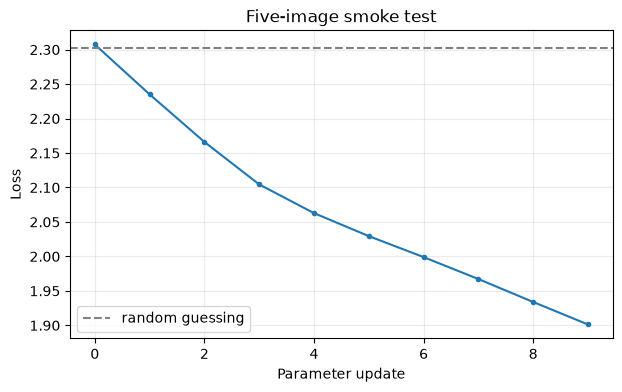

In [31]:
# training it on a small amount of data and seeing if it works
# training the naive implementation will take way too long 
X_tiny = X_train[:5]
y_tiny = y_train[:5]

np.random.seed(0)
tiny_model = ConvNet(
    input_dim=input_dim,
    conv_configs=conv_configs,
    fc_configs=fc_configs,
    num_classes=num_classes,
)

initial_scores = tiny_model.loss(X_tiny)
initial_loss, _ = softmax_loss(initial_scores, y_tiny)

tiny_solver = Solver(
    tiny_model, X_tiny, y_tiny, update_rule=sgd,
    lr=1e-2, batch_size=5, epochs=10,
)
tiny_loss_history = tiny_solver.train()
final_scores = tiny_model.loss(X_tiny)
final_loss, _ = softmax_loss(final_scores, y_tiny)
tiny_predictions = final_scores.argmax(axis=1)
tiny_accuracy = np.mean(tiny_predictions == y_tiny)

print(f"Initial loss: {initial_loss:.4f}")
print(f"Final loss:   {final_loss:.4f}")
print("Labels:     ", y_tiny)
print("Predictions:", tiny_predictions)
print(f"Smoke-test accuracy: {tiny_accuracy:.0%}")

plt.figure(figsize=(7, 4))
plt.plot(tiny_loss_history, marker="o", markersize=3)
plt.axhline(np.log(num_classes), color="gray", linestyle="--", label="random guessing")
plt.xlabel("Parameter update")
plt.ylabel("Loss")
plt.title("Five-image smoke test")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

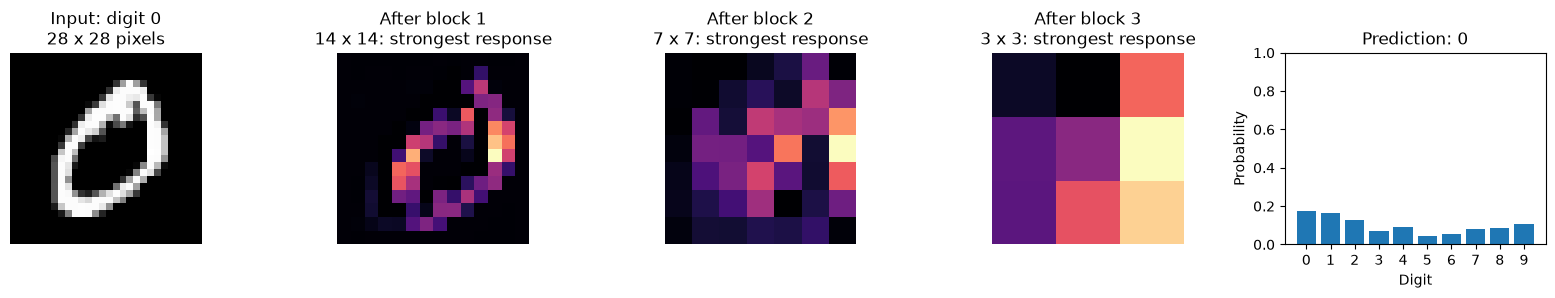

Bright areas mean at least one filter responded strongly there.
Spatial sizes: 28 x 28 -> 14 x 14 -> 7 x 7 -> 3 x 3


In [32]:
# One training example
image_index = 1
x = X_tiny[image_index:image_index + 1]
out = x
block_activations = []

num_blocks = tiny_model.num_conv // 2
for block in range(num_blocks):
    for layer in range(2):
        number = 2 * block + layer + 1
        config = tiny_model.conv_configs[number - 1]

        out, _ = conv_forward(
            out,
            tiny_model.params[f"W{number}"],
            tiny_model.params[f"b{number}"],
            {
                "stride": config["stride"],
                "pad": config["pad"],
            },
        )
        out, _ = relu_forward(out)

    out, _ = max_pool_forward(out, tiny_model.pool_params[block])
    block_activations.append(out)

scores = tiny_model.loss(x)[0]
scores -= scores.max()
probabilities = np.exp(scores) / np.exp(scores).sum()
prediction = probabilities.argmax()
original = x[0, 0] * 255.0 + mean_img[0]

fig, axes = plt.subplots(1, num_blocks + 2, figsize=(3.2 * (num_blocks + 2), 3))
axes[0].imshow(original, cmap="gray")
axes[0].set_title(f"Input: digit {y_tiny[image_index]}\n{input_dim[1]} x {input_dim[2]} pixels")
axes[0].axis("off")

for block, activation in enumerate(block_activations):
    strongest_response = activation[0].max(axis=0)
    height, width = strongest_response.shape
    axes[block + 1].imshow(strongest_response, cmap="magma", interpolation="nearest")
    axes[block + 1].set_title(f"After block {block + 1}\n{height} x {width}: strongest response")
    axes[block + 1].axis("off")

axes[-1].bar(np.arange(num_classes), probabilities)
axes[-1].set_xticks(np.arange(num_classes))
axes[-1].set_ylim(0, 1)
axes[-1].set_title(f"Prediction: {prediction}")
axes[-1].set_xlabel("Digit")
axes[-1].set_ylabel("Probability")

plt.tight_layout()
plt.show()
sizes = [f"{input_dim[1]} x {input_dim[2]}"]
sizes.extend(f"{a.shape[2]} x {a.shape[3]}" for a in block_activations)
print("Bright areas mean at least one filter responded strongly there.")
print("Spatial sizes:", " -> ".join(sizes))